In [ ]:
import numpy as np

In [ ]:
inputs = np.array([1, 2, 3])

In [ ]:
weights = np.array([0.2, 0.8, -0.5])

In [ ]:
bias = 2

In [ ]:
output = np.dot(inputs, weights) + bias

print("Neuron Output:", output)


Neuron Output: 2.3


In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = 2

print("Sigmoid Output:", sigmoid(x))


Sigmoid Output: 0.8807970779778823


In [ ]:
from sklearn.neural_network import MLPClassifier

# XOR Dataset
X = [[0,0],
     [0,1],
     [1,0],
     [1,1]]

y = [0,1,1,0]


In [ ]:
model = MLPClassifier(hidden_layer_sizes=(4,),
                      max_iter=5000,
                      random_state=42)

model.fit(X, y)

print("Predictions:")
print(model.predict(X))


Predictions:
[0 0 0 0]


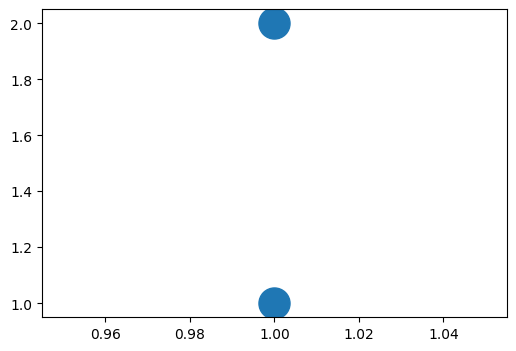

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Input Layer
plt.scatter([1,1],[1,2],s=500)


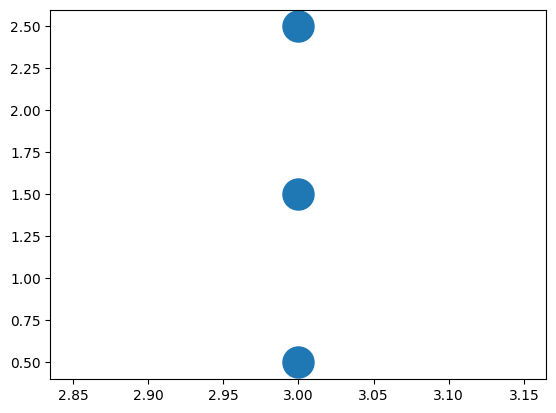

In [ ]:
plt.scatter([3,3,3],[0.5,1.5,2.5],s=500)

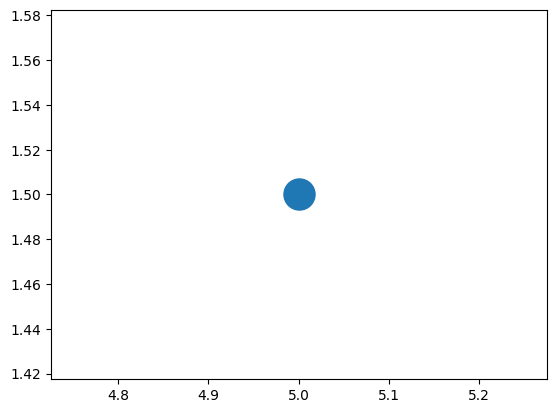

In [ ]:
plt.scatter([5],[1.5],s=500)

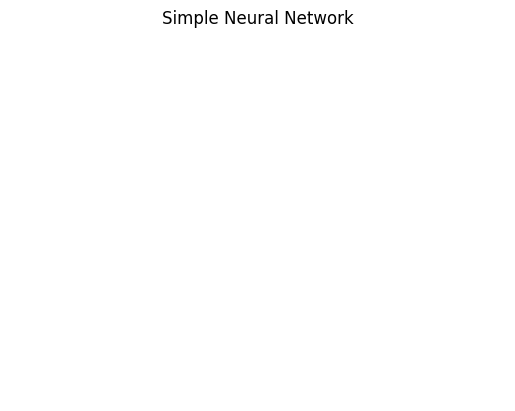

In [ ]:
plt.title("Simple Neural Network")
plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7738 - loss: 0.6307 - val_accuracy: 0.8445 - val_loss: 0.4321
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8463 - loss: 0.4229 - val_accuracy: 0.8572 - val_loss: 0.3867
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3826 - val_accuracy: 0.8698 - val_loss: 0.3577
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8679 - loss: 0.3594 - val_accuracy: 0.8758 - val_loss: 0.3410
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8733 - loss: 0.3406 - val_accuracy: 0.8787 - val_loss: 0.3376
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8795 - loss: 0.3268 - val_accuracy: 0.8831 - val_loss: 0.3315
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8831 - loss: 0.3133 - val_accuracy: 0.8817 - val_loss: 0.3274
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8870 - loss: 0.3043 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8739 - loss: 0.3432

Test Accuracy: 0.8738999962806702


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))



Confusion Matrix
[[862   1  26  23   3   0  77   0   8   0]
 [  3 969   3  19   3   0   2   0   1   0]
 [ 14   0 883   9  56   0  36   0   2   0]
 [ 35   8  13 893  37   0  12   0   2   0]
 [  0   0 196  30 733   0  40   0   1   0]
 [  0   0   0   0   0 955   0  33   2  10]
 [170   2 145  26  72   0 574   0  11   0]
 [  0   0   0   0   0  12   0 976   0  12]
 [  3   0   8   3   7   1   4   4 970   0]
 [  0   0   0   1   0  14   1  60   0 924]]


In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))




Classification Report
              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.69      0.88      0.78      1000
           3       0.89      0.89      0.89      1000
           4       0.80      0.73      0.77      1000
           5       0.97      0.95      0.96      1000
           6       0.77      0.57      0.66      1000
           7       0.91      0.98      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.98      0.92      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



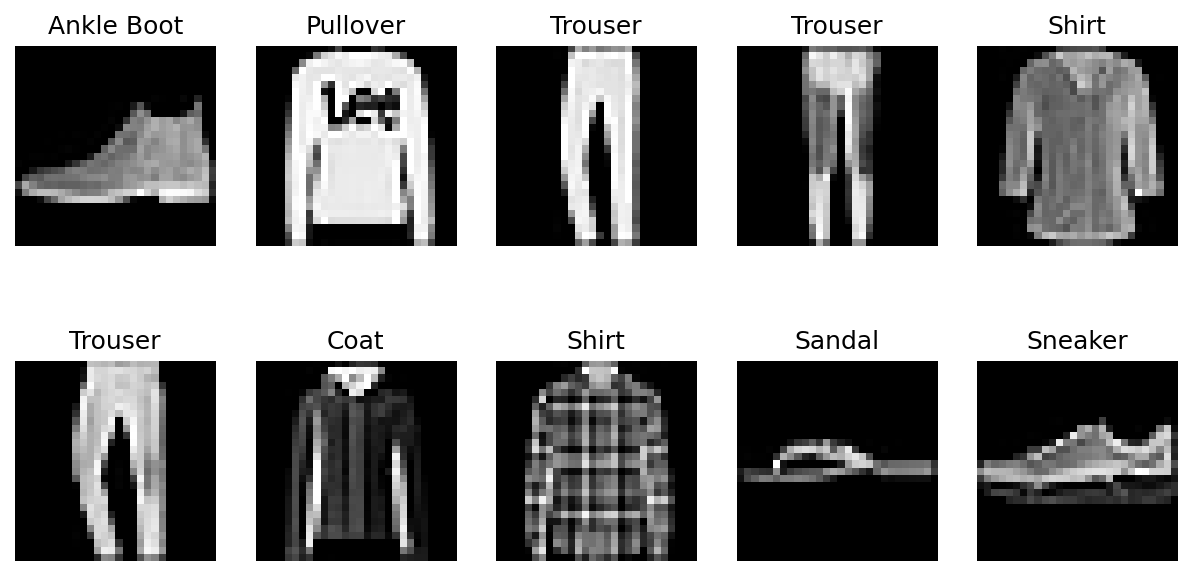

In [ ]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag','Ankle Boot'
]

plt.figure(figsize=(10,5), dpi=150)

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()

## Deep Learning for Intel Image Classification

This section will develop a deep learning model using TensorFlow to classify images from the Intel Image Classification Dataset. We'll cover data loading, preprocessing, model definition, training, and evaluation.

### 1. Setup Kaggle API and Download Dataset

To download the dataset from Kaggle, you need to:

1.  **Create a Kaggle account** if you don't have one.
2.  Go to your Kaggle profile, click 'Account', and scroll down to the 'API' section. Click 'Create New API Token' to download `kaggle.json`.
3.  In Colab, go to 'Secrets' (the key icon on the left panel), click 'Add new secret'.
4.  Set the name to `KAGGLE_USERNAME` and the value to your Kaggle username.
5.  Set the name to `KAGGLE_KEY` and the value to your Kaggle API key (from `kaggle.json`).

Alternatively, you can manually upload the `kaggle.json` file. Create a new folder named `.kaggle` in your Google Drive and upload `kaggle.json` to it. Then run `!pip install kaggle` and `!mkdir ~/.kaggle && cp /content/drive/MyDrive/.kaggle/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json` in a code cell.

In [ ]:
# Install Kaggle library
!pip install kaggle

# Import necessary modules
import os
from google.colab import userdata

# Setup Kaggle API credentials
# Colab Secrets automatically handles KAGGLE_USERNAME and KAGGLE_KEY
# Make sure to add your Kaggle username and key to Colab Secrets

# Download the dataset
dataset_name = 'puneet6060/intel-image-classification'
print(f"Downloading dataset: {dataset_name}...")
!kaggle datasets download -d {dataset_name}
print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:10<00:00, 35.8MB/s]

Download complete.


In [ ]:
# Extract the dataset
import zipfile

zip_file_name = 'intel-image-classification.zip'
extraction_path = 'intel_image_classification_dataset'

print(f"Extracting {zip_file_name}...")
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print("Extraction complete.")

# Verify extraction
print("Contents of the extracted dataset:")
!ls {extraction_path}/seg_train/seg_train

Extracting intel-image-classification.zip...
Extraction complete.
Contents of the extracted dataset:
buildings  forest  glacier  mountain  sea  street


### 2. Load and Preprocess Data

In [ ]:
import tensorflow as tf
import os

# Define paths to the dataset
dataset_base_path = 'intel_image_classification_dataset'
train_dir = os.path.join(dataset_base_path, 'seg_train', 'seg_train')
test_dir = os.path.join(dataset_base_path, 'seg_test', 'seg_test')
pred_dir = os.path.join(dataset_base_path, 'seg_pred', 'seg_pred') # Directory for prediction images

# Parameters for image loading
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load testing data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle test data
    seed=42
)

# Get class names BEFORE splitting train_ds, as .skip() removes the attribute
class_names = train_ds.class_names

# It's good practice to create a validation split from the training data
val_size = int(len(train_ds) * 0.2)
val_ds = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds)}")

print(f"Class names: {class_names}")

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Number of training batches: 352
Number of validation batches: 87
Number of test batches: 94


AttributeError: '_SkipDataset' object has no attribute 'class_names'

In [ ]:
# Configure dataset for performance
def preprocess(image, label):
    # Cast image to float32 BEFORE division for proper normalization
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

TypeError: in user code:

    File "/tmp/ipykernel_3432/3545595486.py", line 4, in preprocess  *
        image = tf.cast(image / 255.0, tf.float32)

    TypeError: `x` and `y` must have the same dtype, got tf.uint8 != tf.float32.


### 3. Build the CNN Model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Flatten the output for the dense layers
    layers.Flatten(),

    # Dense layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(len(class_names), activation='softmax') # Output layer with softmax for multi-class classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,566,922 (36.49 MB)

 Trainable params: 9,566,474 (36.49 MB)

 Non-trainable params: 448 (1.75 KB)

### 4. Compile and Train the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 20 # You can adjust this number
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.5343 - loss: 4.2392 - val_accuracy: 0.6153 - val_loss: 4.5342
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6568 - loss: 1.2810 - val_accuracy: 0.6767 - val_loss: 1.2855
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7230 - loss: 0.8301 - val_accuracy: 0.7543 - val_loss: 0.8952
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7495 - loss: 0.7370 - val_accuracy: 0.7626 - val_loss: 0.7566
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.7797 - loss: 0.6148 - val_accuracy: 0.7654 - val_loss: 0.7797
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7821 - loss: 0.6239 - val_accuracy: 0.7769 - val_loss: 0.8003
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8079 - loss: 0.5444 - val_accuracy: 0.7845 - val_loss: 0.7092
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8261 - loss: 0.4935 - 

### 5. Evaluate Model Performance

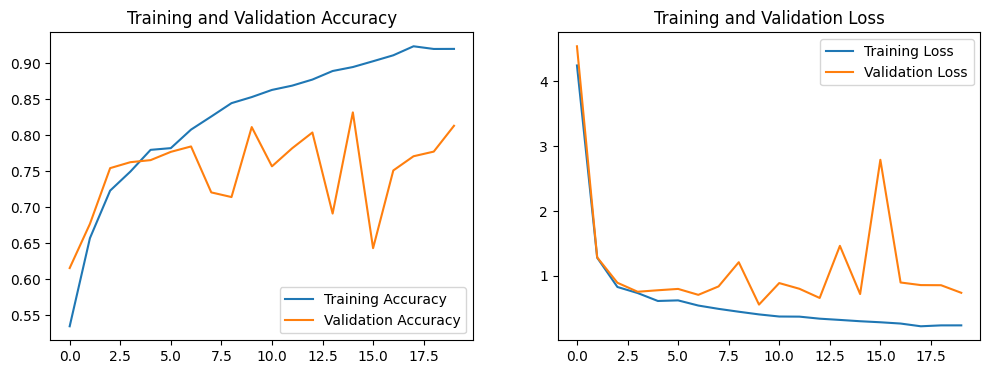

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7983 - loss: 0.8382

Test Loss: 0.8382
Test Accuracy: 0.7983
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━

ValueError: Number of classes, 6, does not match size of target_names, 10. Try specifying the labels parameter

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluate on test set
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for confusion matrix and classification report
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Ensure class_names are correctly fetched from the dataset
# class_names was already set in cell dd8d5a68 before the split, which is correct.
# We just need to make sure the global variable `class_names` from dd8d5a68 is used here.

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

### 6. Visualize Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


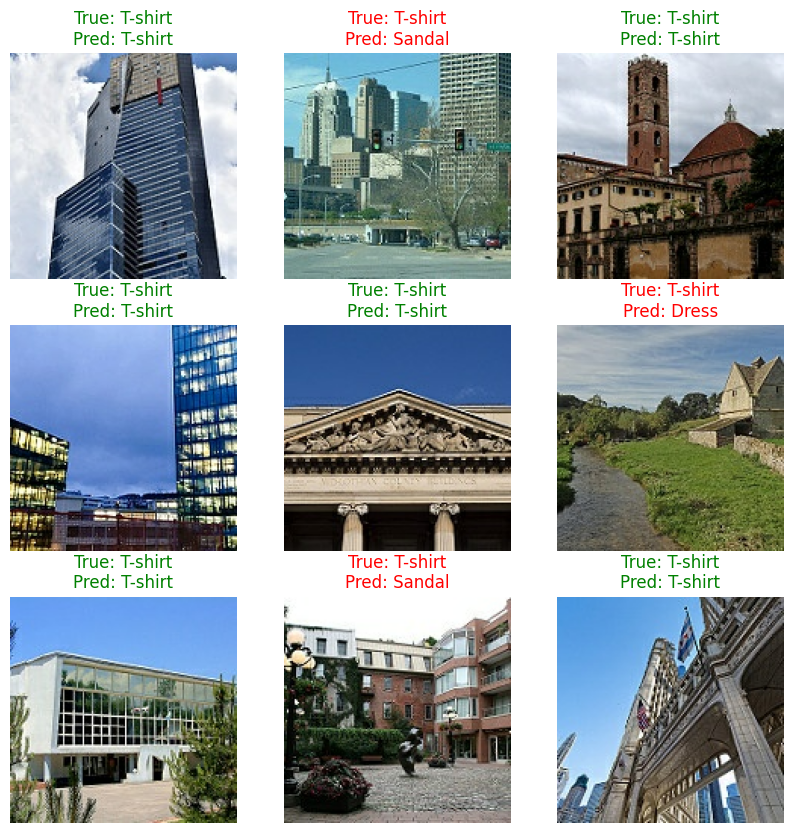

In [ ]:
# Take a batch from the test dataset to visualize
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]
        color = "green" if predicted_label == true_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")
    plt.show()

The model has been built, trained, and evaluated. You can now examine the training and validation curves, the test accuracy, the confusion matrix, and the classification report to understand its performance. The sample predictions also give a visual sense of how well the model is classifying images. If you have further questions or want to refine the model, let me know!